# RavenStack — Customer Churn Prediction
## Notebook 03: Model Comparison & Selection

**Alur notebook:**
1. Setup & load data
2. Train/test split + SMOTE
3. Training 4 model (LR, DT, RF, XGBoost)
4. Perbandingan performa — tabel + visualisasi
5. Threshold tuning tiap model
6. Pilih model terbaik
7. Hyperparameter tuning model terpilih
8. Evaluasi final + SHAP
9. Simpan model

---
## 0. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import os, json
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    recall_score, precision_score, f1_score, accuracy_score
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import shap
import joblib

plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

SEED   = 42
COLORS = {
    'Logistic Regression': '#378ADD',
    'Decision Tree'      : '#EF9F27',
    'Random Forest'      : '#1D9E75',
    'XGBoost'            : '#7F77DD',
}
os.makedirs('../reports', exist_ok=True)
os.makedirs('../models',  exist_ok=True)

print('✅ Library siap')

✅ Library siap


---
## 1. Load & Validasi Dataset

In [2]:
df = pd.read_csv('../data/processed/ravenstack_features_for_modeling.csv')

# Konversi boolean ke int
bool_cols = df.select_dtypes(include='bool').columns.tolist()
df[bool_cols] = df[bool_cols].astype(int)

X = df.drop(columns=['target'])
y = df['target']

print(f'Shape   : {df.shape}')
print(f'Fitur   : {X.shape[1]}')
print(f'Churn   : {y.sum()} ({y.mean()*100:.1f}%)')
print(f'No churn: {(y==0).sum()} ({(y==0).mean()*100:.1f}%)')

Shape   : (500, 84)
Fitur   : 83
Churn   : 110 (22.0%)
No churn: 390 (78.0%)


---
## 2. Train/Test Split + SMOTE

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

smote = SMOTE(random_state=SEED, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print('Train (setelah SMOTE):')
print(f'  Tidak Churn : {(y_train_res==0).sum()}')
print(f'  Churn       : {(y_train_res==1).sum()}')
print(f'Test (asli)   : {len(y_test)} baris | Churn: {y_test.sum()}')

# Scaler untuk Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled  = scaler.transform(X_test)

Train (setelah SMOTE):
  Tidak Churn : 312
  Churn       : 312
Test (asli)   : 100 baris | Churn: 22


---
## 3. Training 4 Model

> Semua model dilatih dengan kondisi yang sama (data SMOTE, random_state=42)  
> agar perbandingannya *apple-to-apple*.

In [4]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=SEED, C=1.0
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=6, class_weight='balanced', random_state=SEED
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=SEED, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        random_state=SEED, eval_metric='logloss', verbosity=0
    ),
}

trained = {}
print('Training model...')
for name, model in models.items():
    # LR pakai data yang sudah di-scale
    X_fit = X_train_scaled if name == 'Logistic Regression' else X_train_res
    model.fit(X_fit, y_train_res)
    trained[name] = model
    print(f'  ✅ {name}')

print('\nSemua model selesai dilatih!')

Training model...
  ✅ Logistic Regression
  ✅ Decision Tree
  ✅ Random Forest
  ✅ XGBoost

Semua model selesai dilatih!


---
## 4. Evaluasi & Perbandingan Semua Model

In [5]:
# Target metrik bisnis
TARGET = {'Recall': 0.80, 'Precision': 0.70, 'F1': 0.75, 'AUC-ROC': 0.85}

results = []
probas  = {}

for name, model in trained.items():
    X_ev   = X_test_scaled if name == 'Logistic Regression' else X_test
    proba  = model.predict_proba(X_ev)[:, 1]
    pred   = model.predict(X_ev)
    probas[name] = proba

    results.append({
        'Model'    : name,
        'Recall'   : recall_score(y_test, pred),
        'Precision': precision_score(y_test, pred, zero_division=0),
        'F1'       : f1_score(y_test, pred),
        'AUC-ROC'  : roc_auc_score(y_test, proba),
        'Accuracy' : accuracy_score(y_test, pred),
    })

results_df = pd.DataFrame(results).set_index('Model').round(4)

# Tandai kolom yang memenuhi target
def highlight(val, col):
    return 'background-color: #d4edda; color: #155724' if val >= TARGET.get(col, 0) \
           else 'background-color: #f8d7da; color: #721c24'

styled = results_df.style.apply(
    lambda col: [highlight(v, col.name) for v in col], axis=0
)

print('=== PERBANDINGAN METRIK SEMUA MODEL ===')
print(f'{"":22} {"Recall":>8} {"Precision":>10} {"F1":>8} {"AUC-ROC":>9} {"Accuracy":>10}')
print('-' * 72)
for name, row in results_df.iterrows():
    rc = '✅' if row['Recall']    >= TARGET['Recall']    else '❌'
    pc = '✅' if row['Precision'] >= TARGET['Precision'] else '❌'
    fc = '✅' if row['F1']        >= TARGET['F1']        else '❌'
    ac = '✅' if row['AUC-ROC']   >= TARGET['AUC-ROC']   else '❌'
    print(f'{name:22} {row["Recall"]:>7.4f}{rc} {row["Precision"]:>9.4f}{pc} '
          f'{row["F1"]:>7.4f}{fc} {row["AUC-ROC"]:>8.4f}{ac} {row["Accuracy"]:>9.4f}')
print()
print(f'Target: Recall≥{TARGET["Recall"]} | Precision≥{TARGET["Precision"]} | F1≥{TARGET["F1"]} | AUC-ROC≥{TARGET["AUC-ROC"]}')

styled

=== PERBANDINGAN METRIK SEMUA MODEL ===
                         Recall  Precision       F1   AUC-ROC   Accuracy
------------------------------------------------------------------------
Logistic Regression     0.1818❌    0.3077❌  0.2286❌   0.6416❌    0.7300
Decision Tree           0.3182❌    0.3043❌  0.3111❌   0.5315❌    0.6900
Random Forest           0.0455❌    0.3333❌  0.0800❌   0.6672❌    0.7700
XGBoost                 0.1364❌    0.5000❌  0.2143❌   0.6416❌    0.7800

Target: Recall≥0.8 | Precision≥0.7 | F1≥0.75 | AUC-ROC≥0.85


,Recall,Precision,F1,AUC-ROC,Accuracy
Model,,,,,
Logistic Regression,0.181800,0.307700,0.228600,0.641600,0.730000
Decision Tree,0.318200,0.304300,0.311100,0.531500,0.690000
Random Forest,0.045500,0.333300,0.080000,0.667200,0.770000
XGBoost,0.136400,0.500000,0.214300,0.641600,0.780000


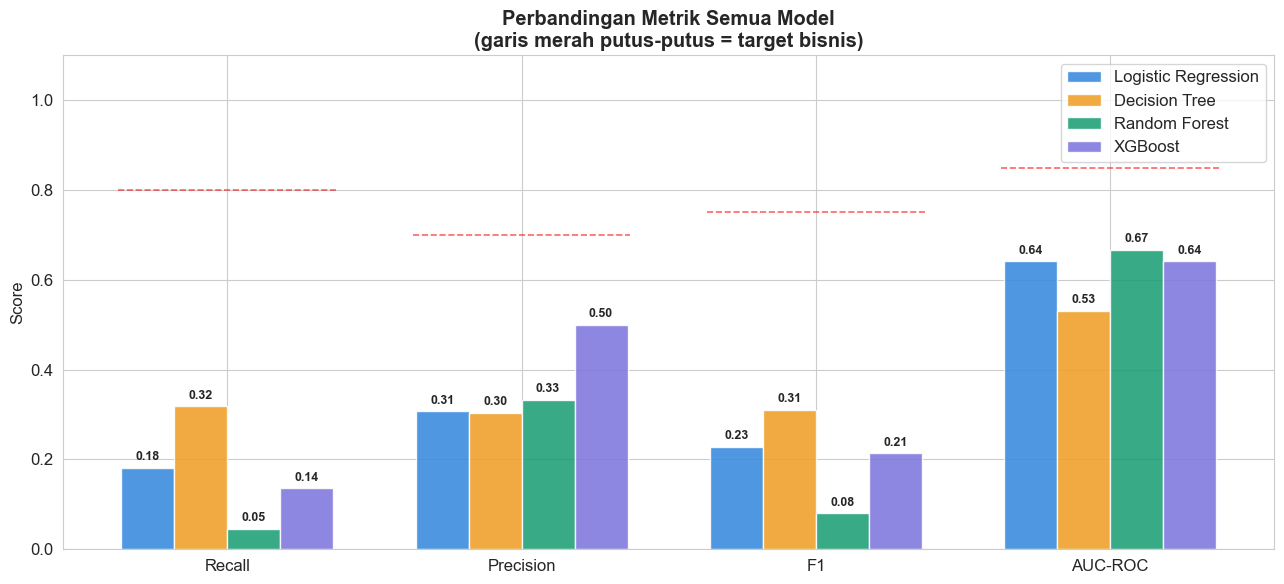

💾 Tersimpan: reports/01_model_comparison.png


In [6]:
# Visualisasi perbandingan
metrics = ['Recall', 'Precision', 'F1', 'AUC-ROC']
model_names = results_df.index.tolist()
x = np.arange(len(metrics))
width = 0.18

fig, ax = plt.subplots(figsize=(13, 6))

for i, name in enumerate(model_names):
    vals = [results_df.loc[name, m] for m in metrics]
    bars = ax.bar(x + i*width, vals, width, label=name,
                   color=COLORS[name], alpha=0.88, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Garis target
target_vals = [TARGET[m] for m in metrics]
for xi, tv in zip(x + 1.5*width, target_vals):
    ax.hlines(tv, xi - 1.5*width - 0.1, xi + 1.5*width + 0.1,
               colors='red', linestyles='--', linewidth=1.2, alpha=0.6)

ax.set_xticks(x + 1.5*width)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Perbandingan Metrik Semua Model\n(garis merah putus-putus = target bisnis)', fontweight='bold')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('../reports/01_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Tersimpan: reports/01_model_comparison.png')

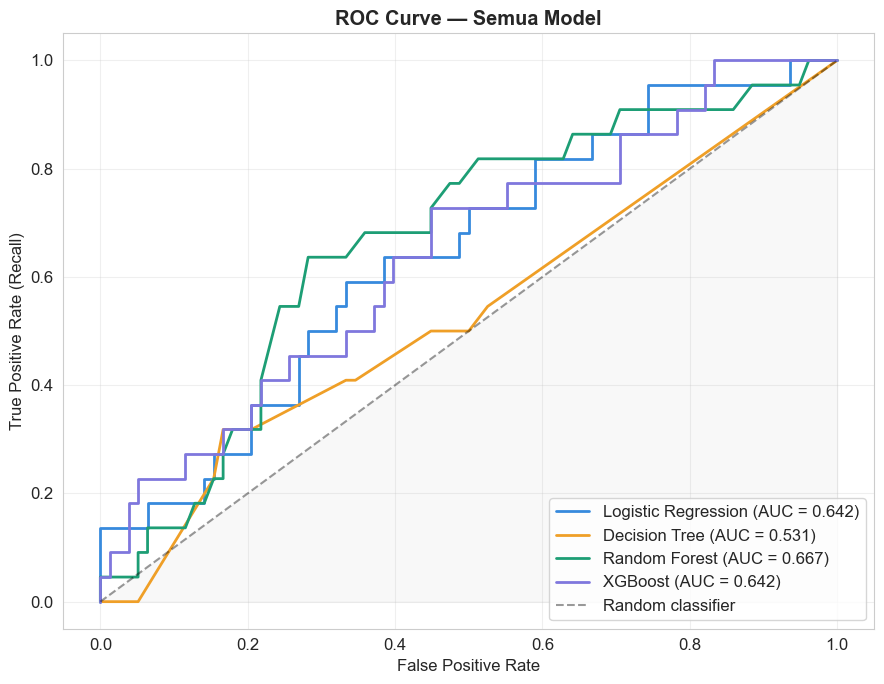

💾 Tersimpan: reports/02_roc_all_models.png


In [7]:
# ROC Curve semua model dalam satu grafik
fig, ax = plt.subplots(figsize=(9, 7))

for name, proba in probas.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})',
             color=COLORS[name], linewidth=2)

ax.plot([0,1], [0,1], 'k--', alpha=0.4, label='Random classifier')
ax.fill_between([0,1], [0,1], alpha=0.05, color='gray')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC Curve — Semua Model', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/02_roc_all_models.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Tersimpan: reports/02_roc_all_models.png')

---
## 5. Threshold Tuning Setiap Model

> Dengan threshold default (0.5), Recall mungkin belum optimal.  
> Kita cari threshold terbaik untuk **setiap model** secara adil.

In [8]:
def find_best_threshold(y_true, y_proba, target_recall=0.80):
    """Cari threshold dengan Recall >= target, F1 tertinggi."""
    thresholds = np.arange(0.05, 0.95, 0.01)
    best = {'threshold': 0.5, 'recall': 0, 'precision': 0, 'f1': 0}
    for t in thresholds:
        pred = (y_proba >= t).astype(int)
        rec  = recall_score(y_true, pred, zero_division=0)
        prec = precision_score(y_true, pred, zero_division=0)
        f1   = f1_score(y_true, pred, zero_division=0)
        if rec >= target_recall and f1 > best['f1']:
            best = {'threshold': t, 'recall': rec, 'precision': prec, 'f1': f1}
    return best

tuned_results = []
best_thresholds = {}

print(f'Threshold tuning — target Recall ≥ 0.80\n')
print(f'{"Model":22} {"Threshold":>10} {"Recall":>8} {"Precision":>10} {"F1":>8}')
print('-' * 64)

for name, proba in probas.items():
    best = find_best_threshold(y_test, proba)
    best_thresholds[name] = best['threshold']
    status = '✅' if best['recall'] >= 0.80 else '⚠️ '
    print(f"{name:22} {best['threshold']:>10.2f} {best['recall']:>7.4f}{status} "
          f"{best['precision']:>9.4f}  {best['f1']:>7.4f}")
    tuned_results.append({
        'Model'    : name,
        'Threshold': best['threshold'],
        'Recall'   : best['recall'],
        'Precision': best['precision'],
        'F1'       : best['f1'],
        'AUC-ROC'  : roc_auc_score(y_test, proba),
    })

tuned_df = pd.DataFrame(tuned_results).set_index('Model').round(4)
print()
tuned_df

Threshold tuning — target Recall ≥ 0.80

Model                   Threshold   Recall  Precision       F1
----------------------------------------------------------------
Logistic Regression          0.13  0.8182✅    0.2727   0.4091
Decision Tree                0.50  0.0000⚠️     0.0000   0.0000
Random Forest                0.29  0.8182✅    0.2903   0.4286
XGBoost                      0.50  0.0000⚠️     0.0000   0.0000



,Threshold,Recall,Precision,F1,AUC-ROC
Model,,,,,
Logistic Regression,0.13,0.8182,0.2727,0.4091,0.6416
Decision Tree,0.50,0.0000,0.0000,0.0000,0.5315
Random Forest,0.29,0.8182,0.2903,0.4286,0.6672
XGBoost,0.50,0.0000,0.0000,0.0000,0.6416


---
## 6. Pilih Model Terbaik

In [9]:
# Scoring: prioritas Recall, tiebreak dengan F1 lalu AUC-ROC
tuned_df['score'] = (
    tuned_df['Recall']  * 0.50 +
    tuned_df['F1']      * 0.30 +
    tuned_df['AUC-ROC'] * 0.20
)

BEST_MODEL_NAME = tuned_df['score'].idxmax()
best_model      = trained[BEST_MODEL_NAME]
best_threshold  = best_thresholds[BEST_MODEL_NAME]

print('=' * 50)
print(f'  MODEL TERPILIH : {BEST_MODEL_NAME}')
print(f'  Threshold      : {best_threshold:.2f}')
print(f'  Recall         : {tuned_df.loc[BEST_MODEL_NAME, "Recall"]:.4f}')
print(f'  Precision      : {tuned_df.loc[BEST_MODEL_NAME, "Precision"]:.4f}')
print(f'  F1-Score       : {tuned_df.loc[BEST_MODEL_NAME, "F1"]:.4f}')
print(f'  AUC-ROC        : {tuned_df.loc[BEST_MODEL_NAME, "AUC-ROC"]:.4f}')
print('=' * 50)
print()
print('Skor semua model (Recall×0.5 + F1×0.3 + AUC×0.2):')
print(tuned_df[['Recall','F1','AUC-ROC','score']].sort_values('score', ascending=False))

  MODEL TERPILIH : Random Forest
  Threshold      : 0.29
  Recall         : 0.8182
  Precision      : 0.2903
  F1-Score       : 0.4286
  AUC-ROC        : 0.6672

Skor semua model (Recall×0.5 + F1×0.3 + AUC×0.2):
                     Recall      F1  AUC-ROC    score
Model                                                
Random Forest        0.8182  0.4286   0.6672  0.67112
Logistic Regression  0.8182  0.4091   0.6416  0.66015
XGBoost              0.0000  0.0000   0.6416  0.12832
Decision Tree        0.0000  0.0000   0.5315  0.10630


---
## 7. Hyperparameter Tuning Model Terpilih

> GridSearchCV dengan 5-fold StratifiedKFold, scoring = Recall

In [10]:
param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10],
        'solver': ['lbfgs', 'saga'],
        'max_iter': [500, 1000]
    },
    'Decision Tree': {
        'max_depth': [4, 6, 8, 10],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 6, 10],
        'min_samples_split': [2, 5]
    },
    'XGBoost': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 4, 5],
        'learning_rate': [0.05, 0.1, 0.15],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    }
}

base_models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=SEED),
    'Decision Tree'      : DecisionTreeClassifier(class_weight='balanced', random_state=SEED),
    'Random Forest'      : RandomForestClassifier(class_weight='balanced', random_state=SEED, n_jobs=-1),
    'XGBoost'            : XGBClassifier(random_state=SEED, eval_metric='logloss', verbosity=0),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
X_fit = X_train_scaled if BEST_MODEL_NAME == 'Logistic Regression' else X_train_res

print(f'GridSearchCV untuk: {BEST_MODEL_NAME}')
print('Mohon tunggu...')

grid = GridSearchCV(
    estimator=base_models[BEST_MODEL_NAME],
    param_grid=param_grids[BEST_MODEL_NAME],
    scoring='recall',
    cv=cv,
    n_jobs=-1,
    verbose=0
)
grid.fit(X_fit, y_train_res)

TUNED_MODEL = grid.best_estimator_
print(f'\n✅ Selesai!')
print(f'Best params : {grid.best_params_}')
print(f'Best Recall (CV): {grid.best_score_:.4f}')

GridSearchCV untuk: Random Forest
Mohon tunggu...

✅ Selesai!
Best params : {'max_depth': 6, 'min_samples_split': 2, 'n_estimators': 200}
Best Recall (CV): 0.8527


---
## 8. Evaluasi Final

In [11]:
X_ev_final = X_test_scaled if BEST_MODEL_NAME == 'Logistic Regression' else X_test
y_proba_final = TUNED_MODEL.predict_proba(X_ev_final)[:, 1]

# Re-tune threshold pada model yang sudah di-tune
best_t = find_best_threshold(y_test, y_proba_final)
FINAL_THRESHOLD = best_t['threshold']
y_pred_final  = (y_proba_final >= FINAL_THRESHOLD).astype(int)

rec  = recall_score(y_test, y_pred_final)
prec = precision_score(y_test, y_pred_final, zero_division=0)
f1   = f1_score(y_test, y_pred_final)
auc  = roc_auc_score(y_test, y_proba_final)
acc  = accuracy_score(y_test, y_pred_final)

print('=' * 55)
print(f'  EVALUASI FINAL — {BEST_MODEL_NAME} (Tuned)')
print('=' * 55)
print(classification_report(y_test, y_pred_final,
      target_names=['Tidak Churn','Churn']))
print(f'Threshold   : {FINAL_THRESHOLD:.2f}')
print()
print('Vs Target Bisnis:')
print(f'  Recall    : {rec:.4f}  | Target ≥ 0.80 → {"✅" if rec >= 0.80 else "❌"}')
print(f'  Precision : {prec:.4f}  | Target ≥ 0.70 → {"✅" if prec >= 0.70 else "❌"}')
print(f'  F1-Score  : {f1:.4f}  | Target ≥ 0.75 → {"✅" if f1  >= 0.75 else "❌"}')
print(f'  AUC-ROC   : {auc:.4f}  | Target ≥ 0.85 → {"✅" if auc >= 0.85 else "❌"}')

  EVALUASI FINAL — Random Forest (Tuned)
              precision    recall  f1-score   support

 Tidak Churn       0.90      0.46      0.61        78
       Churn       0.30      0.82      0.44        22

    accuracy                           0.54       100
   macro avg       0.60      0.64      0.52       100
weighted avg       0.77      0.54      0.57       100

Threshold   : 0.37

Vs Target Bisnis:
  Recall    : 0.8182  | Target ≥ 0.80 → ✅
  Precision : 0.3000  | Target ≥ 0.70 → ❌
  F1-Score  : 0.4390  | Target ≥ 0.75 → ❌
  AUC-ROC   : 0.6597  | Target ≥ 0.85 → ❌


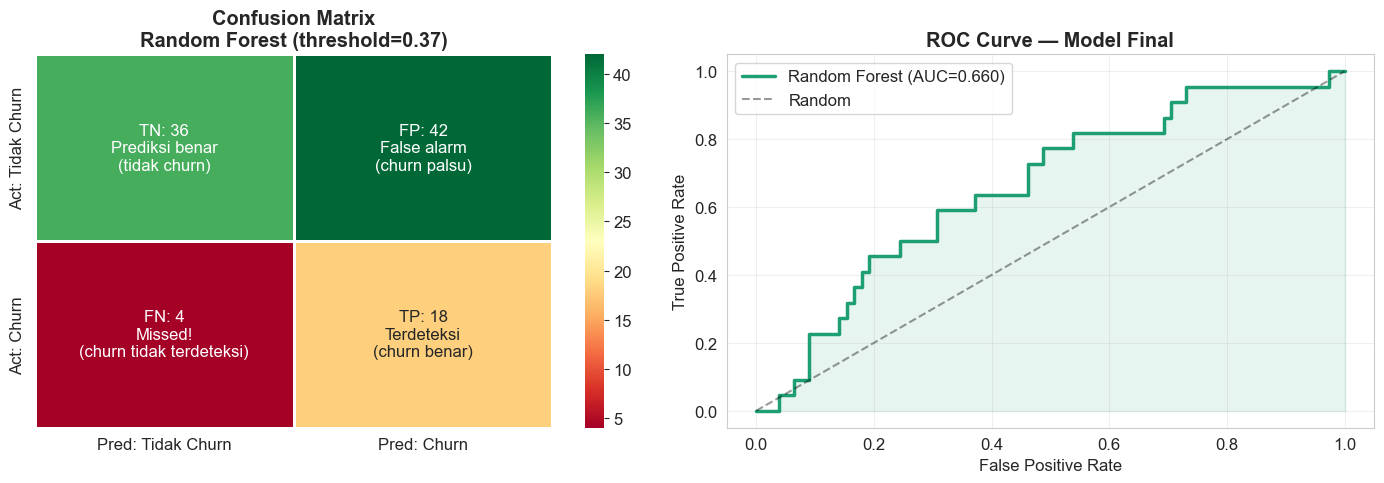

💾 Tersimpan: reports/03_final_evaluation.png


In [12]:
# Confusion Matrix + ROC Curve final
cm = confusion_matrix(y_test, y_pred_final)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_labels = np.array([
    [f'TN: {tn}\nPrediksi benar\n(tidak churn)', f'FP: {fp}\nFalse alarm\n(churn palsu)'],
    [f'FN: {fn}\nMissed!\n(churn tidak terdeteksi)', f'TP: {tp}\nTerdeteksi\n(churn benar)']
])
sns.heatmap(cm, annot=cm_labels, fmt='', ax=axes[0], cmap='RdYlGn',
             linewidths=2,
             xticklabels=['Pred: Tidak Churn','Pred: Churn'],
             yticklabels=['Act: Tidak Churn','Act: Churn'])
axes[0].set_title(f'Confusion Matrix\n{BEST_MODEL_NAME} (threshold={FINAL_THRESHOLD:.2f})', fontweight='bold')

fpr, tpr, _ = roc_curve(y_test, y_proba_final)
axes[1].plot(fpr, tpr, color=COLORS.get(BEST_MODEL_NAME,'#378ADD'), linewidth=2.5,
              label=f'{BEST_MODEL_NAME} (AUC={auc:.3f})')
axes[1].plot([0,1],[0,1],'k--', alpha=0.4, label='Random')
axes[1].fill_between(fpr, tpr, alpha=0.1, color=COLORS.get(BEST_MODEL_NAME,'#378ADD'))
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Model Final', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/03_final_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Tersimpan: reports/03_final_evaluation.png')

---
## 9. Feature Importance + SHAP

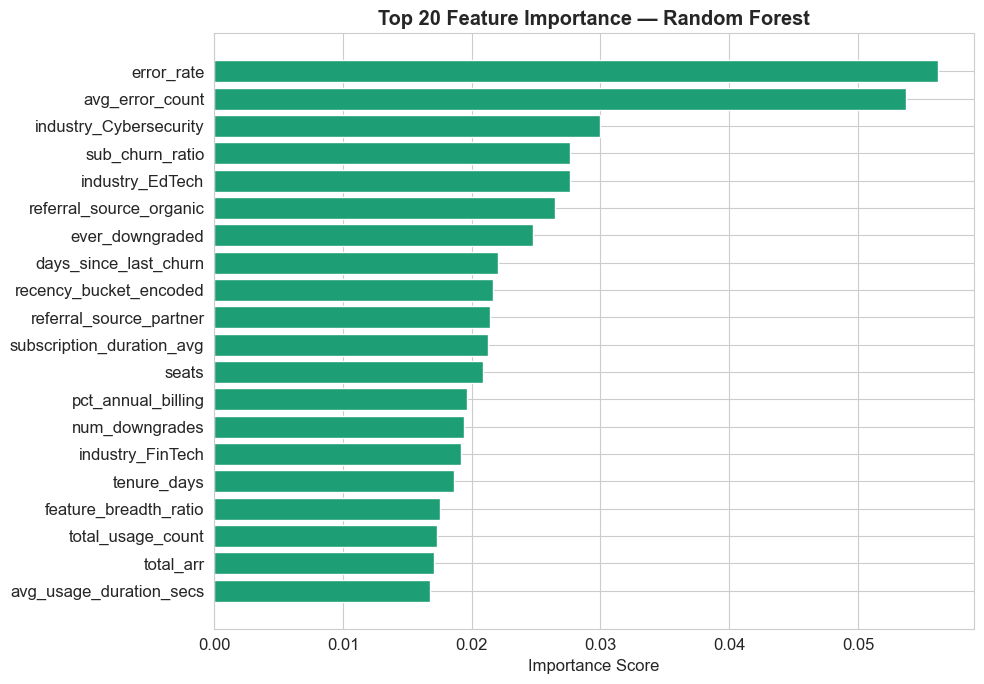

💾 Tersimpan: reports/04_feature_importance.png

Top 10 fitur:
                feature  importance
             error_rate    0.056202
        avg_error_count    0.053761
 industry_Cybersecurity    0.029957
        sub_churn_ratio    0.027665
        industry_EdTech    0.027596
referral_source_organic    0.026460
        ever_downgraded    0.024777
  days_since_last_churn    0.022061
 recency_bucket_encoded    0.021641
referral_source_partner    0.021439


In [13]:
# Feature importance (untuk model berbasis tree)
if hasattr(TUNED_MODEL, 'feature_importances_'):
    imp_df = pd.DataFrame({
        'feature'   : X.columns,
        'importance': TUNED_MODEL.feature_importances_
    }).sort_values('importance', ascending=False).head(20)

    plt.figure(figsize=(10, 7))
    plt.barh(imp_df['feature'][::-1], imp_df['importance'][::-1],
              color=COLORS.get(BEST_MODEL_NAME,'#378ADD'), edgecolor='white')
    plt.xlabel('Importance Score')
    plt.title(f'Top 20 Feature Importance — {BEST_MODEL_NAME}', fontweight='bold')
    plt.tight_layout()
    plt.savefig('../reports/04_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('💾 Tersimpan: reports/04_feature_importance.png')
    print('\nTop 10 fitur:')
    print(imp_df.head(10).to_string(index=False))
else:
    print(f'{BEST_MODEL_NAME} tidak memiliki feature_importances_ → gunakan SHAP di cell berikutnya')

Menghitung SHAP values...


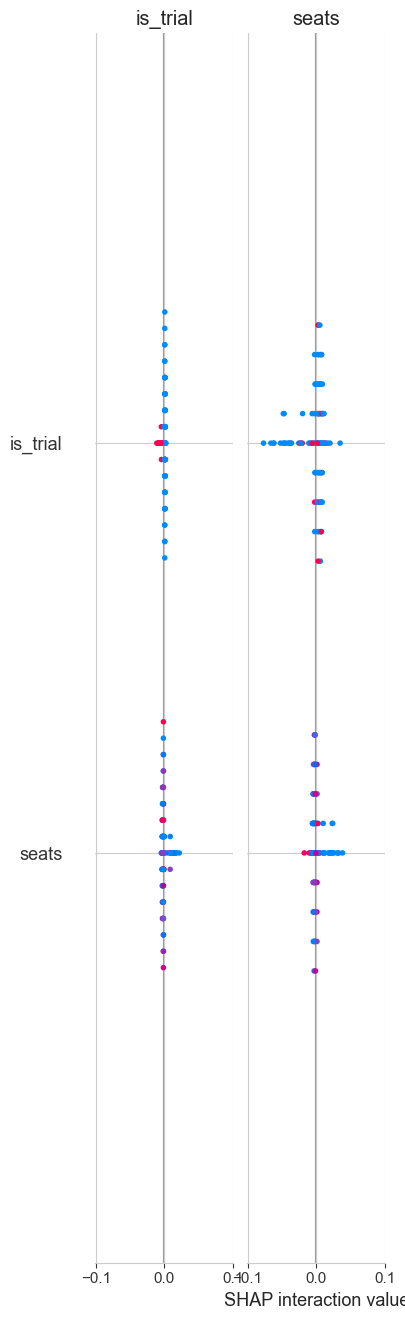

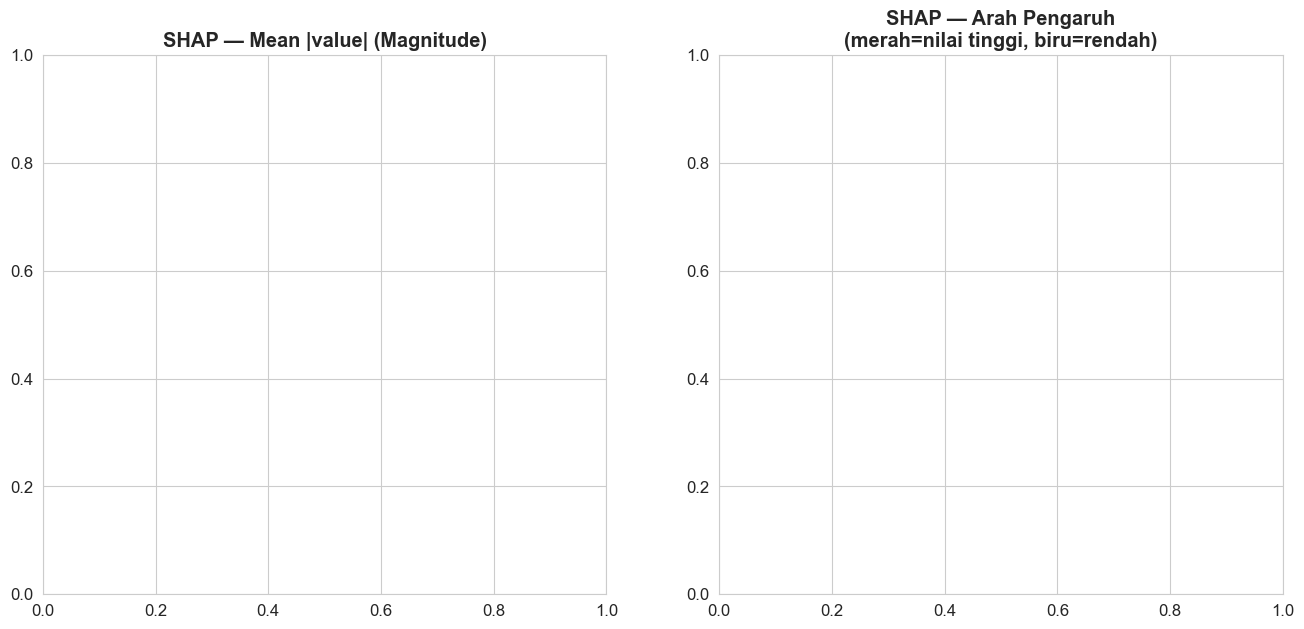

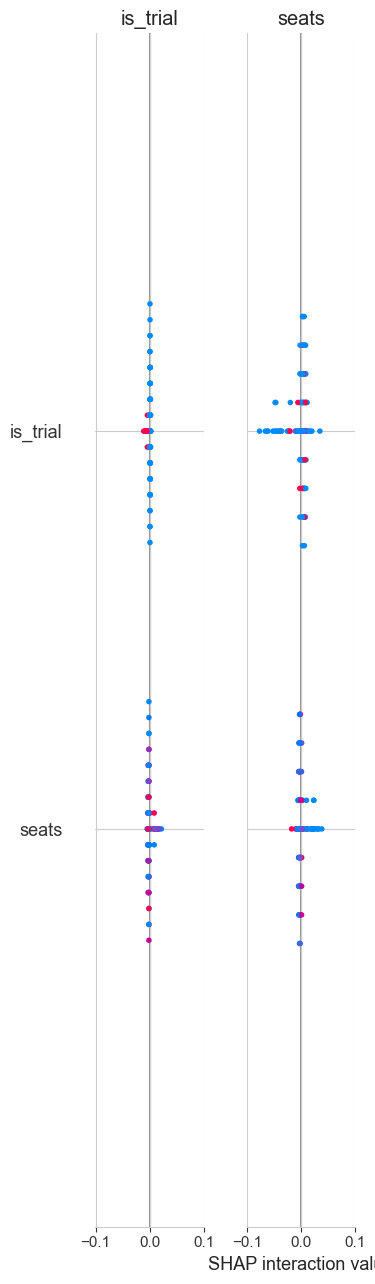

💾 Tersimpan: reports/05_shap_analysis.png

Cara baca plot kanan:
  Titik merah jauh ke KANAN → nilai tinggi = dorong CHURN
  Titik biru jauh ke KIRI  → nilai rendah  = dorong CHURN


In [14]:
# SHAP — berlaku untuk semua jenis model
print('Menghitung SHAP values...')
X_shap = X_test_scaled if BEST_MODEL_NAME == 'Logistic Regression' else X_test

if BEST_MODEL_NAME in ['XGBoost', 'Random Forest', 'Decision Tree']:
    explainer   = shap.TreeExplainer(TUNED_MODEL)
    shap_values = explainer.shap_values(X_shap)
    if isinstance(shap_values, list):      # RF mengembalikan list [class0, class1]
        shap_values = shap_values[1]
else:
    explainer   = shap.LinearExplainer(TUNED_MODEL, X_shap)
    shap_values = explainer.shap_values(X_shap)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

plt.sca(axes[0])
shap.summary_plot(shap_values, X_shap, plot_type='bar', max_display=15, show=False)
axes[0].set_title('SHAP — Mean |value| (Magnitude)', fontweight='bold')

plt.sca(axes[1])
shap.summary_plot(shap_values, X_shap, max_display=15, show=False)
axes[1].set_title('SHAP — Arah Pengaruh\n(merah=nilai tinggi, biru=rendah)', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/05_shap_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Tersimpan: reports/05_shap_analysis.png')
print()
print('Cara baca plot kanan:')
print('  Titik merah jauh ke KANAN → nilai tinggi = dorong CHURN')
print('  Titik biru jauh ke KIRI  → nilai rendah  = dorong CHURN')

---
## 10. Risk Scoring & Simpan Model

In [15]:
# Risk scoring seluruh dataset
X_all = df.drop(columns=['target']).copy()
bool_all = X_all.select_dtypes(include='bool').columns
X_all[bool_all] = X_all[bool_all].astype(int)
X_all_ev = scaler.transform(X_all) if BEST_MODEL_NAME == 'Logistic Regression' else X_all

df_risk = df.copy()
df_risk['churn_probability'] = TUNED_MODEL.predict_proba(X_all_ev)[:, 1]
df_risk['churn_predicted']   = (df_risk['churn_probability'] >= FINAL_THRESHOLD).astype(int)
df_risk['risk_category'] = pd.cut(
    df_risk['churn_probability'],
    bins=[0, 0.3, 0.5, 0.7, 1.0],
    labels=['Low Risk','Medium Risk','High Risk','Critical Risk']
)

print('Distribusi Risk Category:')
print(df_risk['risk_category'].value_counts().sort_index())

# Simpan
risk_cols = ['churn_probability','churn_predicted','risk_category',
             'target','total_mrr','tenure_days','avg_satisfaction_score']
risk_cols = [c for c in risk_cols if c in df_risk.columns]
df_risk[risk_cols].sort_values('churn_probability', ascending=False)\
    .to_csv('../data/processed/ravenstack_risk_scores.csv', index=False)

print('\nTop 10 pelanggan paling berisiko:')
print(df_risk[risk_cols].sort_values('churn_probability', ascending=False).head(10).to_string())
print('\n💾 Tersimpan: data/processed/ravenstack_risk_scores.csv')

Distribusi Risk Category:
Low Risk         203
Medium Risk      180
High Risk        103
Critical Risk     14
Name: risk_category, dtype: int64

Top 10 pelanggan paling berisiko:
     churn_probability  churn_predicted  risk_category  target  total_mrr  tenure_days  avg_satisfaction_score
292           0.757467                1  Critical Risk       1      16984           54                     3.0
25            0.749548                1  Critical Risk       1      10162          666                     4.5
122           0.747938                1  Critical Risk       1      37312          506                     3.0
331           0.738247                1  Critical Risk       1      42999          382                     4.0
395           0.726944                1  Critical Risk       1      29884          311                     4.0
232           0.725633                1  Critical Risk       1      30055          681                     4.0
324           0.721689                1  Cri

In [16]:
# Simpan model + metadata
joblib.dump(TUNED_MODEL, f'../models/best_model_{BEST_MODEL_NAME.lower().replace(" ","_")}.pkl')
joblib.dump(scaler,      '../models/scaler.pkl')

metadata = {
    'best_model'    : BEST_MODEL_NAME,
    'best_params'   : grid.best_params_,
    'threshold'     : float(FINAL_THRESHOLD),
    'metrics_final' : {
        'recall'   : float(round(rec, 4)),
        'precision': float(round(prec,4)),
        'f1'       : float(round(f1,  4)),
        'auc_roc'  : float(round(auc, 4)),
    },
    'all_models_comparison': tuned_df[['Recall','Precision','F1','AUC-ROC']].to_dict()
}
with open('../models/model_metadata.json','w') as f:
    json.dump(metadata, f, indent=2)

print('✅ Model tersimpan!')
print(f'   models/best_model_{BEST_MODEL_NAME.lower().replace(" ","_")}.pkl')
print('   models/scaler.pkl')
print('   models/model_metadata.json')
print()
print('=' * 55)
print('  SELESAI — Ringkasan Akhir')
print('=' * 55)
print(f'  Model terbaik : {BEST_MODEL_NAME}')
print(f'  Threshold     : {FINAL_THRESHOLD:.2f}')
print(f'  Recall        : {rec:.4f}  {"✅" if rec >= 0.80 else "❌"}')
print(f'  Precision     : {prec:.4f}  {"✅" if prec >= 0.70 else "❌"}')
print(f'  F1-Score      : {f1:.4f}  {"✅" if f1 >= 0.75 else "❌"}')
print(f'  AUC-ROC       : {auc:.4f}  {"✅" if auc >= 0.85 else "❌"}')

✅ Model tersimpan!
   models/best_model_random_forest.pkl
   models/scaler.pkl
   models/model_metadata.json

  SELESAI — Ringkasan Akhir
  Model terbaik : Random Forest
  Threshold     : 0.37
  Recall        : 0.8182  ✅
  Precision     : 0.3000  ❌
  F1-Score      : 0.4390  ❌
  AUC-ROC       : 0.6597  ❌
